In [1]:
using LinearAlgebra
using Statistics
using Random
using Distributions
using Combinatorics
using NPZ
using JLD2
using Printf
using AbstractGPs
using KernelFunctions
using Base.Threads
using PyPlot
using JSON

import KernelFunctions: kernelmatrix

include("../../../src/qgp_machinery.jl");
using .QuantumGPs

In [2]:
SAVE_FIGS = true

true

In [3]:
if isdefined(Main, :Plots)
    @warn "Plots.jl is currently loaded in this session!"
end

PyPlot.matplotlib.style.use("default")
PyPlot.matplotlib.style.use("../../../config/unified_plots.mplstyle")
plot_args = JSON.parsefile("../../../config/unified_plots.json")

make_kwargs(dict) = Dict(Symbol(k) => v for (k, v) in dict)

make_kwargs (generic function with 1 method)

In [4]:

"""
    noisy_xxyyzz_from_true(true_xxyyzz::Real, nshots::Int; rng=Random.default_rng())

Shot-noise a theoretical value of ⟨XX+YY+ZZ⟩ assuming it is obtained from SWAP via:
    XX+YY+ZZ = 2*SWAP - 1

Model: k0 ~ Binomial(nshots, p0) with p0 = (1+⟨SWAP⟩)/2.
Return noisy estimate of ⟨XX+YY+ZZ⟩.
"""
function noisy_xxyyzz_from_true(true_xxyyzz::Real, nshots; rng::AbstractRNG=Random.default_rng())
    nshots > 0 || throw(ArgumentError("nshots must be positive, got $nshots"))
    if nshots == Inf
        return true_xxyyzz
    end

    s_true = (true_xxyyzz + 1) / 2               # ⟨SWAP⟩
    s_true = clamp(Float64(s_true), -1.0, 1.0)

    p0 = (1 + s_true) / 2                        # Prob(ancilla=0)
    k0 = rand(rng, Binomial(nshots, p0))         # one draw

    s_hat = 2 * (k0 / nshots) - 1                # noisy ⟨SWAP⟩
    return 2 * s_hat - 1                         # noisy ⟨XX+YY+ZZ⟩
end
"""
    xxyyzz_shot_se_from_true(true_xxyyzz::Real, nshots::Int)

Standard error (1σ) for the estimator of <XX+YY+ZZ> under the same model.
Uses Var(ŝ)= (1 - s^2)/N for SWAP and scales by the factor 2.
"""
function xxyyzz_shot_se_from_true(true_xxyyzz::Real, nshots)
    nshots > 0 || throw(ArgumentError("nshots must be positive, got $nshots"))
    if nshots == Inf
        return 0.
    end
    s_true = clamp((true_xxyyzz + 1) / 2, -1.0, 1.0)
    return 2 * sqrt((1 - s_true^2) / nshots)
end


xxyyzz_shot_se_from_true

In [5]:
# ----------------------------------------------------------------------
# GP two kernel sum machinery
# ----------------------------------------------------------------------

"""
    gp_predict(true_outputs, true_overlaps, ntp,
               nshots_obs, nshots_ker, n, m; verbose=false)

Gaussian process regression using a *precomputed* kernel matrix:

  * Select `ntp` training points, evenly spaced in index space.
  * Build a noisy kernel `ker` by sampling each entry.
  * For each test index, build a (ntp+1)×(ntp+1) kernel including that point,
    project to PSD, and run a small GP to get mean and variance.

Returns
  μ         :: Vector{Float64}  (means at test indices)
  σ         :: Vector{Float64}  (stds at test indices, rescaled by binomial(2n,m))
  y_obs     :: Vector{Float64}  (noisy training labels)
  σ_obs     :: Float64          (training noise std)
  train_idxs:: Vector{Int}
"""
function gp_predict_b2b4(
                    n::Int,
                    true_outputs::AbstractVector,
                    true_overlaps2::AbstractMatrix,
                    true_overlaps4::AbstractMatrix,
                    ntp::Int,
                    nshots_obs,
                    nshots_ker;
                    verbose::Bool = false)

    dsize = length(true_outputs)
    @assert size(true_overlaps2, 1) >= dsize
    @assert size(true_overlaps4, 2) >= dsize

    # Base kernel (exact overlaps restricted to dataset size)
    K2 = @view true_overlaps2[1:dsize, 1:dsize]
    K4 = @view true_overlaps4[1:dsize, 1:dsize]

    # Noisy kernel estimate (shot noise on kernel)
    ker2, ker_vars2 = add_noise_2_kernel(K2, nshots_ker; nq=n, m=2)
    ker4, ker_vars4 = add_noise_2_kernel(K4, nshots_ker; nq=n, m=4)

    # Apply kernel scaling
    kernel_factor2 = 2*factorial(2) / (2n)^2  # 1 / dl_2  #  factorial(2) / (2n)^2  # binomial(2n, 2) * factorial(2) / (2n)^2  # assumes kernel normalized by module dim
    kernel_factor4 = factorial(4) / (2n)^4  # 1 / dl_4  #  factorial(4) / (2n)^4  # binomial(2n, 4) * factorial(4) / (2n)^4  # assumes kernel normalized by module dim
    ker2 .*= kernel_factor2
    ker_vars2 .*= kernel_factor2^2
    ker4 .*= kernel_factor4
    ker_vars4 .*= kernel_factor4^2

    ker = ker2 + ker4
    ker_vars = ker_vars2 + ker_vars4 

    # Training / test split (unchanged)
    # train_idxs = floor.(Int, collect(range(1, dsize; length = ntp)))
    # train_idxs  = collect(1:ntp)
    train_idxs = Int[]
    for k in 1:ntp
        if k%2==1
            push!(train_idxs, (k+1)÷2)
        else
            push!(train_idxs, dsize + 1 - k÷2)
        end
    end
    train_idxs = unique(sort(train_idxs))
    # train_idxs = [1]
    # test_idxs  = setdiff(collect(1:dsize), train_idxs)  # No test indices used, predict all points

    # Noisy observations on training points
    σ_obs  = [xxyyzz_shot_se_from_true(true_outputs[i], nshots_obs) for i in train_idxs]  # 1 / sqrt(nshots_obs)
    σ²_obs = σ_obs .^ 2
    println("σ_obs: ", σ_obs)
    println("σ_obs pauli: ", [pauli_mean_var(true_outputs[i], nshots_obs) for i in train_idxs])
    #y_obs  = [sample_pauli_mean(true_outputs[i], nshots_obs) for i in train_idxs]
    y_obs  = [noisy_xxyyzz_from_true(true_outputs[i], nshots_obs) for i in train_idxs]

    
    # Send to QGP machinery for fitting and prediction
    qgp_res = qgp_fit_predict(ker, y_obs, train_idxs; 
                              obs_σ²=σ²_obs, ker_σ²=ker_vars)

    μ_pred = qgp_res.mean
    σ_pred = qgp_res.std

    return μ_pred, σ_pred, y_obs, σ_obs, train_idxs
end


gp_predict_b2b4

In [6]:
# load data

n = 50
d = 2^n
base = "../../data/"

true_outputs_m2     = npzread(joinpath(base, "true_outputs_m2_$(n)q.npy"))
true_outputs_m4     = npzread(joinpath(base, "true_outputs_m4_$(n)q.npy"))
true_overlaps_m2    = npzread(joinpath(base, "true_overlaps_m2_$(n)q.npy"))
true_overlaps_m4    = npzread(joinpath(base, "true_overlaps_m4_$(n)q.npy"));

In [7]:
true_overlaps_m2 *= d 
true_overlaps_m4 *= d ;

In [8]:
true_outputs  = true_outputs_m2 + true_outputs_m4;

# GP Classification (using Laplace approximation, not Variational Inference)

In [9]:
using AbstractGPs, ApproximateGPs, Distributions, LinearAlgebra
using KernelFunctions, LogExpFunctions, Random
using Zygote, Optim

# [Keep your PrecomputedIndexKernel struct exactly as before]

"""
    classify_laplace(K_full, train_indices, y_train; optimize_scale=false)

Performs GP Classification by reducing the problem to a heteroscedastic GP Regression
on synthetic observations (Laplace Approximation), then delegating to `qgp_fit_predict`.
"""
function classify_laplace(
    K_full::AbstractMatrix, 
    y_train::Vector{Float64},
    train_indices::AbstractVector{<:Integer};
    ker_σ²::Union{Real, AbstractMatrix{<:Real}} = 0.0,
    optimize_scale::Bool=false
)
    # ---------------------------------------------------------
    # A. Scale Optimization 
    # ---------------------------------------------------------
    K_train_base = K_full[train_indices, train_indices]
    sigma_f = 1.0 

    if optimize_scale
        println("Optimizing kernel scale...")
        function nlml(log_params)
            s = exp(log_params[1]); K = s * K_train_base + 1e-6 * I
            f_hat = Zygote.ignore() do
                f = zeros(length(y_train))
                for _ in 1:20 
                    p = logistic.(f); W = Diagonal(p .* (1 .- p))
                    f = (I + K * W) \ (K * (y_train .- p + W * f))
                end
                f
            end
            p = logistic.(f_hat); w_sqrt = sqrt.(p .* (1 .- p))
            K_weighted = K .* (w_sqrt * w_sqrt') # Broadcasting for Zygote stability
            B = Hermitian(I + K_weighted)
            return 0.5*dot(f_hat, K \ f_hat) - sum(logpdf.(Bernoulli.(p), y_train)) + 0.5*logdet(cholesky(B))
        end
        res = optimize(nlml, G->(G.=Zygote.gradient(nlml, G)[1]), [0.0], LBFGS(), Optim.Options(iterations=20))
        sigma_f = exp(Optim.minimizer(res)[1])
        println("Found optimal scale: ", sigma_f)
    end
    
    # Scale the full kernel matrix
    K_scaled = sigma_f * K_full
    K_train = K_scaled[train_indices, train_indices]

    # ---------------------------------------------------------
    # B. Newton-Raphson (Find the Mode)
    # ---------------------------------------------------------
    N_train = length(train_indices)
    f = zeros(N_train) 
    
    for _ in 1:100
        p = logistic.(f)
        W = Diagonal(p .* (1 .- p))
        grad = y_train .- p
        
        # Standard Newton step
        b = K_train * (grad + W * f)
        A = I + K_train * W
        f_new = A \ b
        
        if norm(f_new - f) < 1e-8; f = f_new; break; end
        f = f_new
    end
    f_hat = f

    # ---------------------------------------------------------
    # C. Construct Synthetic Regression Problem
    # ---------------------------------------------------------
    # We map the Classification problem to a Regression problem:
    # y_synthetic ≈ N(f, W⁻¹)
    
    p = logistic.(f_hat)
    
    # 1. Compute Synthetic Noise Variance (1/W)
    # Clamp small probabilities to avoid division by zero (infinite noise)
    min_prob = 1e-8
    p_safe = clamp.(p, min_prob, 1.0 - min_prob)
    w_diag = p_safe .* (1.0 .- p_safe)
    synthetic_noise_vars = 1.0 ./ w_diag
    
    # 2. Compute Synthetic Targets (Working Variables)
    # y_tilde = f_hat + W⁻¹ * (y - p)
    residuals = y_train .- p
    y_synthetic = f_hat .+ (residuals ./ w_diag)

    # ---------------------------------------------------------
    # D. Delegate to QGP Module
    # ---------------------------------------------------------
    
    qgp_res = qgp_fit_predict(
        K_scaled, 
        y_synthetic, 
        train_indices; 
        obs_σ² = synthetic_noise_vars, # Vector of heteroscedastic noise
        ker_σ² = ker_σ²,                  # Kernel is already scaled
    )

    # ---------------------------------------------------------
    # E. Prediction (Probit Transform)
    # ---------------------------------------------------------
    # This includes train predictions
    mu_star = qgp_res.mean
    var_star = qgp_res.var
    
    # Convert Latent Gaussian -> Probability
    # Approximation: p(y=1) ≈ σ(μ / √(1 + π/8 * σ²))
    kappa(v) = 1.0 / sqrt(1.0 + (pi * v) / 8.0)
    predicted_probs = logistic.(kappa.(abs.(var_star)) .* mu_star)

    return predicted_probs, qgp_res  # retursn latent distribution for further analysis if desired
end

classify_laplace

In [10]:
# Plotting helper:
function get_segmented_curve(xs, probs; x_bound=1.0, p_bound=0.5)
    # 1. Define Correctness Logic
    # Returns 1.0 if correct (Blue), 0.0 if incorrect (Red)
    get_color(x, p) = ((x > x_bound) == (p > p_bound)) ? 1.0 : 0.0

    xs_out, ps_out, colors_out = Float64[], Float64[], Float64[]

    for i in 1:length(xs)-1
        x1, p1 = xs[i], probs[i]
        x2, p2 = xs[i+1], probs[i+1]
        
        # Start of segment
        current_color = get_color(x1, p1)
        push!(xs_out, x1)
        push!(ps_out, p1)
        push!(colors_out, current_color)

        # Detect Intersections
        intersections = Tuple{Float64, Float64}[]
        
        # Crosses Probability Threshold (horizontal line)
        if (p1 - p_bound) * (p2 - p_bound) < 0
            t = (p_bound - p1) / (p2 - p1)
            push!(intersections, (x1 + t*(x2-x1), p_bound))
        end
        
        # Crosses Class Boundary (vertical line)
        if (x1 - x_bound) * (x2 - x_bound) < 0
            t = (x_bound - x1) / (x2 - x1)
            push!(intersections, (x_bound, p1 + t*(p2-p1)))
        end
        
        # Sort intersections by x-coordinate (processing left-to-right)
        sort!(intersections, by = v -> v[1])

        # Process Intersections
        for (ix, ip) in intersections
            # 1. End current color segment at intersection
            push!(xs_out, ix)
            push!(ps_out, ip)
            push!(colors_out, current_color)

            # 2. Determine next color by looking slightly ahead
            # (We peek 0.1% of the way to the next point/intersection)
            next_target_x = isempty(intersections) ? x2 : intersections[end][1] 
            peek_x = ix + (x2 - x1) * 1e-4
            peek_p = ip + (p2 - p1) * 1e-4
            next_color = get_color(peek_x, peek_p)

            # 3. Start new color segment at intersection
            push!(xs_out, ix)
            push!(ps_out, ip)
            push!(colors_out, next_color)
            
            current_color = next_color
        end
    end

    # Add final point
    push!(xs_out, xs[end])
    push!(ps_out, probs[end])
    push!(colors_out, get_color(xs[end], probs[end]))

    return xs_out, ps_out, colors_out
end

get_segmented_curve (generic function with 1 method)

B2 kernel min / max: 6.970665053447074 / 50.0
B4 kernel min / max: -11.470771770846593 / 1225.0
Full kernel matrix min / max: -3.5721012578397024 / 1273.4548127504927
Rescaled kernel matrix so that mean diagonal = 20
New kernel diag min / max / mean: 15.293272321684752 / 22.53802944736757 / 20.000000000000004
Training accuracy: 2 / 2 = 1.0%
Test accuracy: 189 / 198 = 0.9545454545454546%


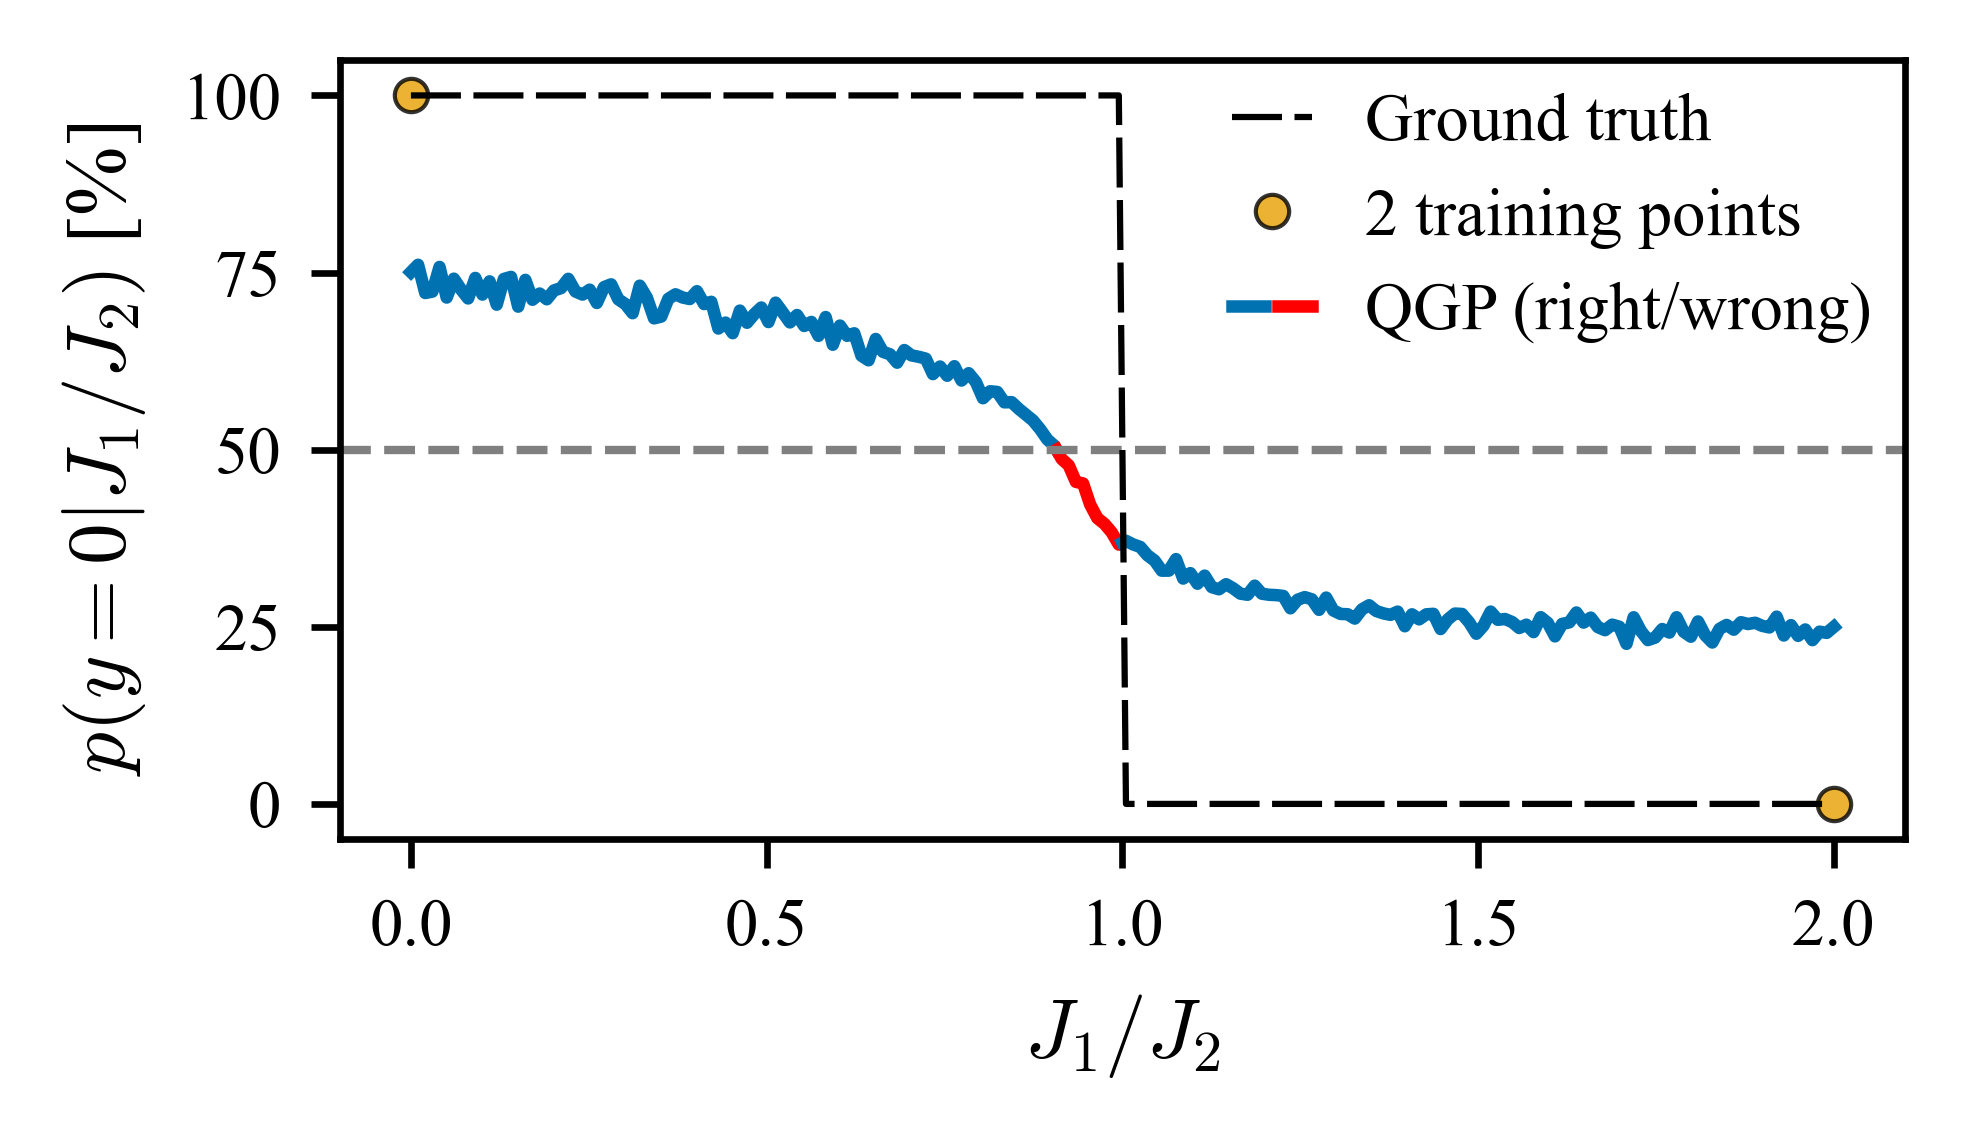

In [11]:
nshots_ker = 10000 
Random.seed!(42)  # for reproducibility

# Prepare data:
dsize = length(true_outputs)
xs = collect(range(0.0, stop=2.0, length=dsize))
xs_idxs = collect(1:dsize)
ys = Float64.(xs .> 1.0)  # binary labels (as 0.0 and 1.0)

#train_idxs = collect(1:dsize)  # all
#train_idxs = collect(1:2:dsize)  # half
train_idxs = [1, dsize]  # minimal training
#train_idxs = [3*dsize ÷ 8, dsize - (3*dsize ÷ 8)]  # minimal training (shifted)
#train_idxs = [Int(round(0.95/2*dsize)), dsize - Int(round(0.95/2*dsize))]  # minimal training
y_train = ys[train_idxs]

# Noisy kernel preprocessing:
dl_2 = binomial(2n, 2)
dl_4 = binomial(2n, 4)
ker2, ker_var2 = add_noise_2_kernel((@view true_overlaps_m2[1:dsize, 1:dsize]), nshots_ker; nq=n, m=2)
ker4, ker_var4 = add_noise_2_kernel((@view true_overlaps_m4[1:dsize, 1:dsize]), nshots_ker; nq=n, m=4)

kernel_factor2 = 1 #factorial(2) / (2n)^2
kernel_factor4 = 1 #factorial(4) / (2n)^4
ker2 .*= kernel_factor2
ker_var2 .*= kernel_factor2^2
ker4 .*= kernel_factor4
ker_var4 .*= kernel_factor4^2

println("B2 kernel min / max: ", minimum(ker2), " / ", maximum(ker2))
println("B4 kernel min / max: ", minimum(ker4), " / ", maximum(ker4))

ker = (ker2 + ker4)
ker_var = ker_var2 + ker_var4  # Approximate total variance (assuming independence)
println("Full kernel matrix min / max: ", minimum(ker), " / ", maximum(ker))
@assert size(ker) == (dsize, dsize) "Kernel shape and dataset size mismatch"


K_gp = copy(ker)
K_gp[train_idxs, train_idxs] = psdify(K_gp[train_idxs, train_idxs]; mode=:shift)  
K_gp = (K_gp + K_gp')/2  # ensure symmetry (should already be the case anyway by now)
full_kernel = K_gp

# rescale kernel so that diagonal entries match a prior target variance
#d = diag(full_kernel)
#full_kernel ./= sqrt.(d * d') (scales to unit diagonal)
target_diag_variance = 20
diag_mean = mean(diag(full_kernel))
full_kernel .*= (target_diag_variance / diag_mean)
println("Rescaled kernel matrix so that mean diagonal = ", target_diag_variance)
println("New kernel diag min / max / mean: ", minimum(diag(full_kernel)), " / ", maximum(diag(full_kernel)), " / ", mean(diag(full_kernel)))

# Classify:
pred_probs, latent_qgp_res = classify_laplace(full_kernel,  y_train, train_idxs; #ker_σ²=ker_var, 
optimize_scale=false)

# Evaluate:
test_idxs = setdiff(xs_idxs, train_idxs)
pred_labels = Float64.(pred_probs .> 0.5)
train_accuracy_freq = sum(pred_labels[train_idxs] .== ys[train_idxs]) 
test_accuracy_freq = sum(pred_labels[test_idxs] .== ys[test_idxs])
println("Training accuracy: $(train_accuracy_freq) / $(length(train_idxs)) = $(train_accuracy_freq / length(train_idxs))%")
println("Test accuracy: $(test_accuracy_freq) / $(length(test_idxs)) = $(test_accuracy_freq / length(test_idxs))%")

# Plot:
# 1. Setup figure
fig_width = plot_args["fig_width_inches_half"]
fig, ax = PyPlot.subplots(figsize=(fig_width, 2))
class_args = plot_args["classification"]
ax.set_xlabel(class_args["xlabel"])
ax.set_ylabel(class_args["ylabel"])

# Flip everything from P(y=1) to P(y=0) for plotting
ys_y0 = 1.0 .- ys
y_train_y0 = 1.0 .- y_train
pred_probs_y0 = 1.0 .- pred_probs

# 2. Segmented Curve Plotting
x_plot, p_plot_y1, c_plot = get_segmented_curve(xs[xs_idxs], pred_probs, x_bound=1.0, p_bound=0.5)
p_plot_y0 = 1.0 .- p_plot_y1

# Extract the base style safely using copy()
gp_kwargs = copy(plot_args["gp_mean"])
correct_color = get(gp_kwargs, "color", "blue")
incorrect_color = "red"
lw = get(gp_kwargs, "linewidth", 2)
ls = get(gp_kwargs, "linestyle", "-")

# Dynamically fetch the label from JSON (e.g., "QGP")
gp_label = get(gp_kwargs, "label", "QGP")

# --- VISUAL ARTIFACT FIX: Group contiguous segments ---
# This eliminates the jaggedness by drawing one continuous line per color block
start_idx = 1
for i in 1:(length(x_plot)-1)
    current_c = c_plot[i] == 1.0 ? correct_color : incorrect_color
    next_c = c_plot[i+1] == 1.0 ? correct_color : incorrect_color

    # Plot chunk only if the color is about to change, or we reach the end
    if current_c != next_c || i == length(x_plot) - 1
        end_idx = i + 1
        ax.plot(x_plot[start_idx:end_idx], p_plot_y0[start_idx:end_idx], color=current_c, linewidth=lw, linestyle=ls)
        start_idx = i + 1 # Next segment starts exactly where this one ends
    end
end

# 3. Legend Handling
# Dummy lines for the legend
h_corr = ax.plot([], [], color=correct_color, linewidth=lw, linestyle=ls)[1]
h_inc = ax.plot([], [], color=incorrect_color, linewidth=lw, linestyle=ls)[1]

# 4. Threshold
ax.axhline(0.5, linestyle="--", color="gray", lw=1)

# 5. JSON Styles for Ground Truth and Observations (using copy!)
true_kwargs = copy(plot_args["true_function"])
h_true = ax.plot(xs, ys_y0; make_kwargs(true_kwargs)...)[1]

train_kwargs = copy(plot_args["observations"])

# Prepend the count to the JSON label (e.g., "2 training points")
train_kwargs["label"] = "$(length(train_idxs)) " * get(train_kwargs, "label", "")
h_train = ax.plot(xs[train_idxs], y_train_y0; make_kwargs(train_kwargs)...)[1]

# 6. Y-axis formatting
ax.set_yticks(0:0.25:1)
ax.set_yticklabels(["$(Int(round(v*100)))" for v in 0:0.25:1])

grouped_pred_handle = (h_corr, h_inc)

# ndivide=2 strictly forces Matplotlib to render the handles side-by-side
h_tuple_handler = PyPlot.matplotlib.legend_handler.HandlerTuple(ndivide=2, pad=0.2)

ax.legend([h_true, h_train, grouped_pred_handle],
[true_kwargs["label"], train_kwargs["label"], "$(gp_label) (right/wrong)"],
loc="upper right",
frameon=false,
borderaxespad=0.1,
handlelength=1.2,
handler_map=Dict(grouped_pred_handle => h_tuple_handler))

# 7. Save and display
if SAVE_FIGS
out_dir = "../plots"
isdir(out_dir) || mkpath(out_dir)
fig.savefig(joinpath(out_dir, "gp_classification_n$(n)_shots$(nshots_ker).pdf"), bbox_inches="tight")
end
display(fig)

In [12]:
f_mu = latent_qgp_res.mean
f_std = latent_qgp_res.std
println("Latent std dev at test points: ", f_std)
upper = f_mu .+ f_std
lower = f_mu .- f_std

# calculate correlation coefficient between latent mean and true outputs (-> order parameter)
corr_coeff = cor(f_mu, true_outputs)
println("Correlation coefficient between latent mean and true outputs: ", corr_coeff)  # Note that plotting is done for opposite class than the actual latent variable, hence the negative correlation

Latent std dev at test points: [2.702102739374252, 2.740756219448653, 3.020304059210602, 2.9683258772376164, 2.5976791884605843, 3.0724665977321313, 2.7740951342418523, 3.0043120922553914, 3.0906126230705393, 2.7149380035749, 2.9411910937596732, 2.801886107589542, 3.1320195988067243, 2.842769689113973, 2.6994626857218, 3.19227560759121, 2.7676656768751684, 3.000824648356699, 3.0370189566213672, 3.0123388796034147, 2.8571294695374063, 2.932709981942205, 2.726636919078858, 2.9264692712905886, 3.0717993124591065, 2.848133087591363, 3.065400314230777, 2.8374031053738333, 2.7089606052771664, 3.0641895947496547, 3.088564686183745, 3.2649056098382476, 2.76304447914365, 2.9475285170501815, 3.3518904657498663, 3.185249738122338, 2.9143596175770456, 2.776655665048878, 2.8415506598774574, 2.8076835150070365, 2.738424485839106, 2.97965263463975, 2.9291589340937265, 3.3075798403197716, 3.1872037363189545, 3.2941578480177105, 2.934956702216899, 3.2199336643400946, 3.2564660978103963, 2.8514161619620